# Train Script MobileNet Transformer

## Library Setup

In [1]:
# ================= STANDARD LIB =================
import os
import sys
import json
from datetime import datetime
from collections import Counter

# ================= THIRD PARTY =================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.tensorboard import SummaryWriter

# ================= LOCAL MODULE =================
from utils.dataloader import get_dataloader, get_transforms
from utils.evaluate import evaluate
from models.mobile_net import MobileNetTransformer

# ================= PATH SETUP =================
sys.path.append(os.path.abspath(".."))

# Setup Train Path and DataLoader

In [2]:
BASE_DIR = os.path.abspath("..")

train_path = os.path.join(BASE_DIR, "data/WLBisindo/split/train")
val_path   = os.path.join(BASE_DIR, "data/WLBisindo/split/val")
test_path  = os.path.join(BASE_DIR, "data/WLBisindo/split/test")

train_transform, val_transform = get_transforms()

train_loader, train_dataset = get_dataloader(
    train_path,
    transform=train_transform,
    use_weighted_sampler=True
)

val_loader, val_dataset = get_dataloader(
    val_path,
    transform=val_transform,
    use_weighted_sampler=False
)

test_loader, test_dataset = get_dataloader(
    test_path,
    transform=val_transform,
    use_weighted_sampler=False
)

Class counts: [34 14 32 35 23 30 34 28 13 35 27 32 34 12 21 28 24 29 32 28 25 22 31 14
 35 33 30 26 35 33 32 32]


## Setup Log Experiments and Check Class Total

In [3]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

log_dir = os.path.join(BASE_DIR, "outputs/logs/mobile_net", f"run_{timestamp}")
os.makedirs(log_dir, exist_ok=True)

writer = SummaryWriter(log_dir)

In [4]:
log_file = os.path.join(log_dir, "log.txt")

def log_message(msg):
    print(msg)
    with open(log_file, "a") as f:
        f.write(msg + "\n")

In [5]:
NUM_CLASSES = len(train_loader.dataset.label_map)

model = MobileNetTransformer(num_classes=NUM_CLASSES)

## Check GPU

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for param in model.encoder.features[:-4].parameters():
    param.requires_grad = False

for param in model.encoder.features[-4:].parameters():
    param.requires_grad = True

## Model Fine Tuning

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)  # (B,)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# ===== LOSS FUNCTION =====
criterion = FocalLoss(gamma=2)

In [8]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

# Train Process

## Train Run Script

In [9]:
EPOCHS = 50
patience = 7
counter = 0
best_val_loss = float("inf")

config = {
    "model": "MobileNetTransformer",
    "epochs": 50,
    "lr": 3e-5,
    "weight_decay": 1e-5,
    "batch_size": train_loader.batch_size,
    "num_classes": NUM_CLASSES,
    "transformer_layers": 2
}

with open(os.path.join(log_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for x, y in train_bar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

        # update progress bar
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in val_bar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

            # update progress bar
            val_bar.set_postfix({
                "loss": f"{loss.item():.4f}"
            })

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ===== LOGGING =====
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)

    writer.add_scalar("Overfitting/gap", train_acc - val_acc, epoch)

    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar("LR", current_lr, epoch)

    for name, param in model.named_parameters():
        writer.add_histogram(f"Weights/{name}", param, epoch)

    log_message(f"Epoch {epoch+1}/{EPOCHS}")
    log_message(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    log_message(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
    log_message(f"LR: {current_lr}")
    log_message("-" * 40)

    # ===== SCHEDULER =====
    scheduler.step(val_loss)


    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), os.path.join(log_dir, "best_model.pth"))
        log_message("Best model saved!")

    else:
        counter += 1
        log_message(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            log_message("Early stopping triggered!")
            break


# SAVE LAST MODEL
torch.save(model.state_dict(), os.path.join(log_dir, "last_model.pth"))


Epoch 1/50


Epoch 1/50
Train Loss: 3.3243 | Acc: 0.0224
Val   Loss: 3.2654 | Acc: 0.0055
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 2/50


Epoch 2/50
Train Loss: 3.2776 | Acc: 0.0392
Val   Loss: 3.2017 | Acc: 0.0330
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 3/50


Epoch 3/50
Train Loss: 3.1436 | Acc: 0.0627
Val   Loss: 2.9813 | Acc: 0.0879
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 4/50


Epoch 4/50
Train Loss: 2.9588 | Acc: 0.0817
Val   Loss: 2.5745 | Acc: 0.0879
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 5/50


...

Epoch 46/50
Train Loss: 0.0897 | Acc: 0.9183
Val   Loss: 0.2440 | Acc: 0.8846
LR: 6.25e-06
----------------------------------------
EarlyStopping counter: 1/7

Epoch 47/50


Epoch 47/50
Train Loss: 0.1111 | Acc: 0.9127
Val   Loss: 0.2445 | Acc: 0.8901
LR: 6.25e-06
----------------------------------------
EarlyStopping counter: 2/7

Epoch 48/50


Epoch 48/50
Train Loss: 0.1024 | Acc: 0.9283
Val   Loss: 0.2383 | Acc: 0.8956
LR: 6.25e-06
----------------------------------------
EarlyStopping counter: 3/7

Epoch 49/50


Epoch 49/50
Train Loss: 0.0905 | Acc: 0.9194
Val   Loss: 0.2453 | Acc: 0.8901
LR: 3.125e-06
----------------------------------------
EarlyStopping counter: 4/7

Epoch 50/50


Epoch 50/50
Train Loss: 0.0681 | Acc: 0.9485
Val   Loss: 0.2353 | Acc: 0.8956
LR: 3.125e-06
----------------------------------------
EarlyStopping counter: 5/7


In [10]:
report_path = os.path.join(log_dir, "evaluation.json")

metrics = evaluate(
    model,
    test_loader,
    device,
    save_path=report_path,
    model_name="MobileNetTransformer"
)

Evaluation Metrics:
accuracy: 0.9013
precision: 0.9136
recall: 0.9009
f1: 0.9012
hamming_loss: 0.0987
Experiment logged to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/metrics\experiments.csv


## Model Evaluation

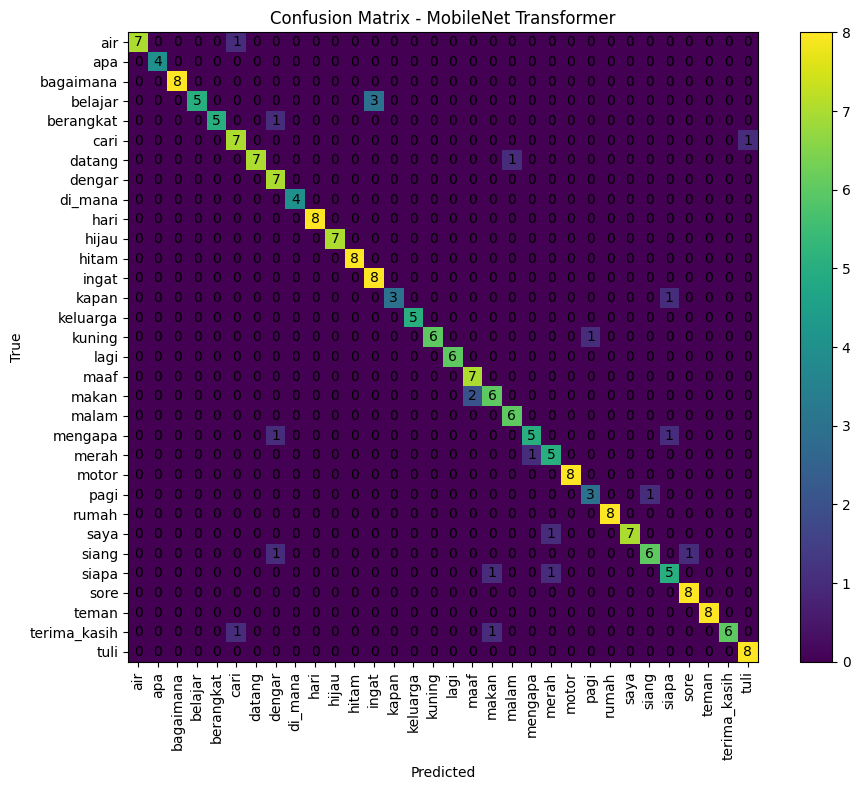

Confusion matrix saved to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/logs/mobile_net\run_20260415_201349\confusion_matrix.png


In [11]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix - MobileNet Transformer")
plt.colorbar()

labels = list(train_loader.dataset.label_map.keys())

plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")

# Tambahin angka di tiap cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()

# save
cm_path = os.path.join(log_dir, "confusion_matrix.png")
plt.savefig(cm_path)

plt.show()

print("Confusion matrix saved to:", cm_path)

In [12]:
print(classification_report(y_true, y_pred))

print("Predicted distribution:", Counter(y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         8
           3       1.00      0.62      0.77         8
           4       1.00      0.83      0.91         6
           5       0.78      0.88      0.82         8
           6       1.00      0.88      0.93         8
           7       0.70      1.00      0.82         7
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         8
          12       0.73      1.00      0.84         8
          13       1.00      0.75      0.86         4
          14       1.00      1.00      1.00         5
          15       1.00      0.86      0.92         7
          16       1.00      1.00      1.00         6
          17       0.78    

In [13]:
print("True count:", Counter(y_true))
print("Pred count:", Counter(y_pred))

True count: Counter({np.int64(30): 8, np.int64(0): 8, np.int64(3): 8, np.int64(26): 8, np.int64(29): 8, np.int64(18): 8, np.int64(12): 8, np.int64(2): 8, np.int64(24): 8, np.int64(6): 8, np.int64(31): 8, np.int64(5): 8, np.int64(28): 8, np.int64(9): 8, np.int64(11): 8, np.int64(25): 8, np.int64(22): 8, np.int64(20): 7, np.int64(7): 7, np.int64(17): 7, np.int64(15): 7, np.int64(27): 7, np.int64(10): 7, np.int64(16): 6, np.int64(19): 6, np.int64(21): 6, np.int64(4): 6, np.int64(14): 5, np.int64(1): 4, np.int64(23): 4, np.int64(8): 4, np.int64(13): 4})
Pred count: Counter({np.int64(12): 11, np.int64(7): 10, np.int64(17): 9, np.int64(28): 9, np.int64(5): 9, np.int64(31): 9, np.int64(29): 8, np.int64(18): 8, np.int64(2): 8, np.int64(24): 8, np.int64(9): 8, np.int64(11): 8, np.int64(22): 8, np.int64(0): 7, np.int64(19): 7, np.int64(27): 7, np.int64(21): 7, np.int64(10): 7, np.int64(6): 7, np.int64(26): 7, np.int64(25): 7, np.int64(16): 6, np.int64(30): 6, np.int64(20): 6, np.int64(15): 6, np

In [ ]:
# TensorBoard Writer Close
writer.flush()
writer.close()

## Evaluation Metrics

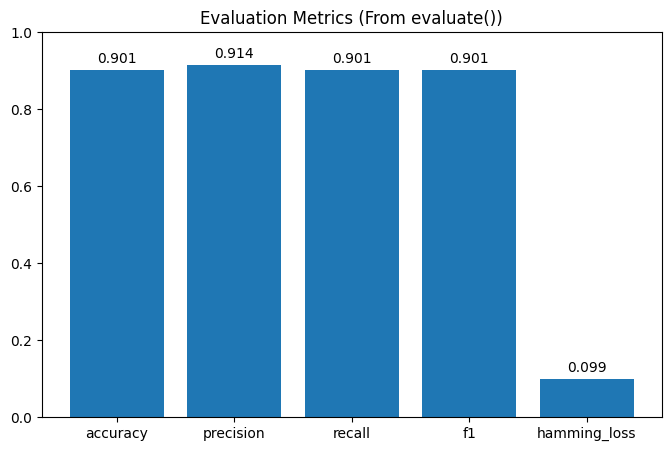

In [15]:
names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8,5))
plt.bar(names, values)
plt.title("Evaluation Metrics (From evaluate())")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.show()

## Model Evaluation Visual Test

In [16]:
correct_samples = []
wrong_samples = []

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(y)):
            sample = (x[i].cpu(), y[i].item(), preds[i].item())

            if preds[i] == y[i] and len(correct_samples) < 20:
                correct_samples.append(sample)

            elif preds[i] != y[i] and len(wrong_samples) < 20:
                wrong_samples.append(sample)

        if len(correct_samples) >= 20 and len(wrong_samples) >= 20:
            break

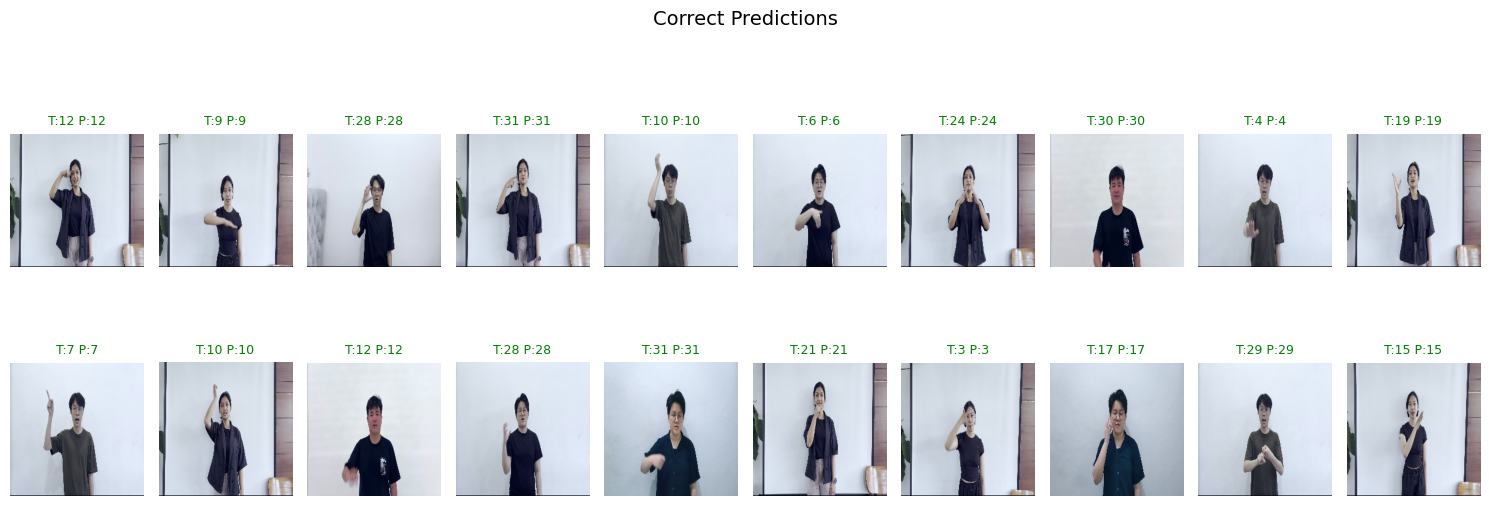

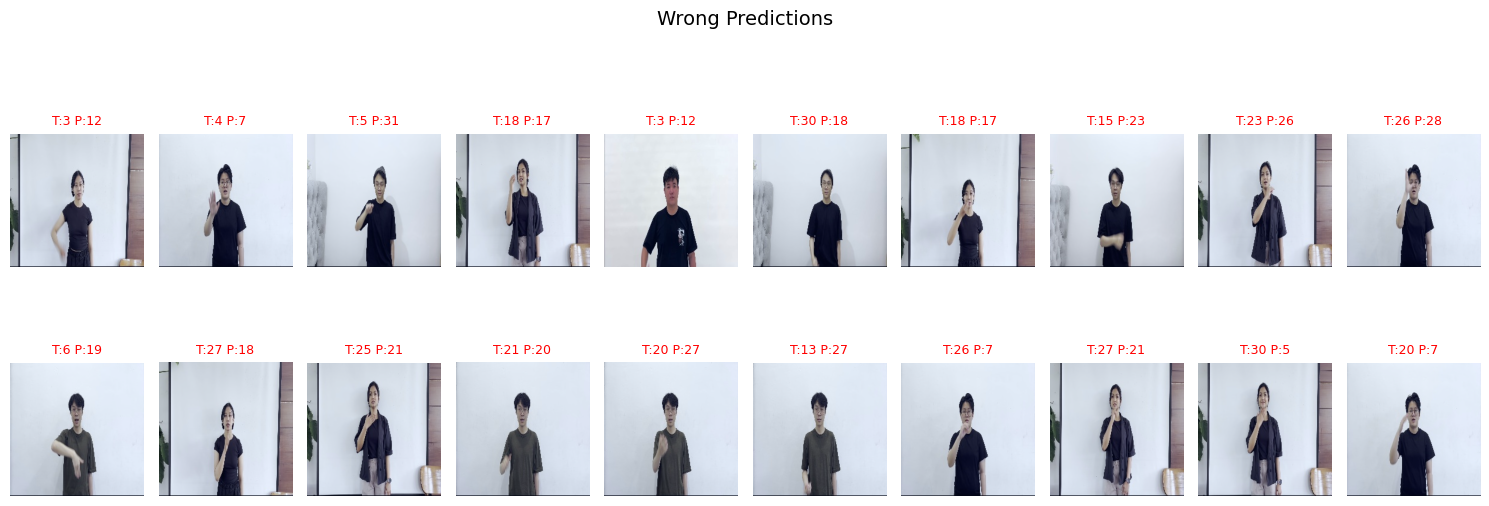

In [17]:
# force style putih
plt.style.use('default')

def plot_samples(samples, title):
    fig = plt.figure(figsize=(15,6), facecolor='white')
    fig.suptitle(title, fontsize=14)

    for i, (frames, true, pred) in enumerate(samples):
        img = frames[len(frames)//2]  # frame tengah

        # ambil 3 channel (RGB)
        img = img[:3]
        img = img.permute(1, 2, 0).numpy()

        # normalize biar aman
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        ax = plt.subplot(2, 10, i+1)
        ax.set_facecolor('white')

        # warna title
        color = "green" if true == pred else "red"

        ax.imshow(img)
        ax.set_title(f"T:{true} P:{pred}", color=color, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_samples(correct_samples, "Correct Predictions")
plot_samples(wrong_samples, "Wrong Predictions")

=== GLOBAL CONFUSION (SIMPLIFIED) ===
TP (Correct) : 201
FP (Wrong)   : 22
FN           : 22
TN           : 0


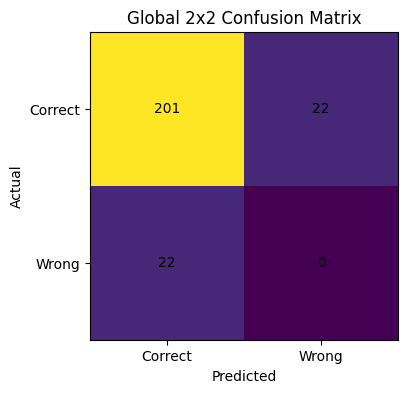

In [18]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# BENAR vs SALAH
tp = np.sum(y_true == y_pred)
fp = np.sum(y_true != y_pred)

# karena multiclass, ini simetris
fn = fp
tn = 0  # tidak terlalu meaningful di multiclass global

print("=== GLOBAL CONFUSION (SIMPLIFIED) ===")
print(f"TP (Correct) : {tp}")
print(f"FP (Wrong)   : {fp}")
print(f"FN           : {fn}")
print(f"TN           : {tn}")

cm_2x2 = np.array([
    [tp, fn],
    [fp, tn]
])

plt.figure(figsize=(4,4))
plt.imshow(cm_2x2)

labels = ["Correct", "Wrong"]

plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Global 2x2 Confusion Matrix")

# isi angka
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_2x2[i, j],
                 ha="center", va="center")

plt.show()